# 1. Imports

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# 2.Parametres et simulateur de marche

In [2]:
# Parametres fixes (Section 5.1, p.27)
T = 1.0
dt = 1.0 / 252
n_steps = int(round(T / dt))  # 252
x0 = 1.0
z = 1.4
r_rate = 0.02

# Gardes-fous numeriques
PHI1_CLIP = (-20.0, 20.0)
PHI2_CLIP = (1e-12, 10.0)
MEAN_CLIP = 1e4
LOG_VAR_CLIP = (-50.0, 50.0)
X_DIFF_CLIP = 1e6

print(f"n_steps={n_steps}, dt={dt:.6f}")

n_steps=252, dt=0.003968


In [3]:
def compute_w_star(rho, T=1.0, x0=1.0, z=1.4):
    e = np.exp(rho**2 * T)
    if abs(e - 1) < 1e-12: return z
    return (z * e - x0) / (e - 1)

def simulate_gbm_prices(mu, sigma, n_prices, dt, S0, rng):
    # Simule n_prices points de GBM
    shocks = rng.normal(0, math.sqrt(dt), size=n_prices - 1)
    log_ret = (mu - 0.5 * sigma**2) * dt + sigma * shocks
    S = np.empty(n_prices)
    S[0] = S0
    S[1:] = S0 * np.exp(np.cumsum(log_ret))
    return S

def discounted_wealth_step(x_t, u_t, s_t, s_tp1, r, dt):
    # Richesse actualisee : x_{t+1} = x_t + u_t * (exp(-r*dt)*S_{t+1}/S_t - 1)
    discounted_return = (s_tp1 * math.exp(-r * dt) / s_t) - 1.0
    return x_t + u_t * discounted_return

# 3. EMV fonctions de base


In [4]:
def V_theta_fn(theta0, theta1, theta2, theta3, w, T, x, t):
    # eq. 44 avec clipping
    x_arr = np.asarray(x, dtype=float)
    t_arr = np.asarray(t, dtype=float)
    xd = np.clip(x_arr - w, -X_DIFF_CLIP, X_DIFF_CLIP)
    return (xd**2) * np.exp(-theta3*(T - t_arr)) + theta2*(t_arr**2) + theta1*t_arr + theta0

def emv_td_error(theta0, theta1, theta2, theta3, w, T, dt, lam, phi1, phi2,
                 vec_xi, vec_xi1, vec_ti, vec_ti1):
    # eq. 42
    vdot = (V_theta_fn(theta0,theta1,theta2,theta3,w,T,vec_xi1,vec_ti1)
          - V_theta_fn(theta0,theta1,theta2,theta3,w,T,vec_xi, vec_ti)) / dt
    return vdot - lam * (phi1 + phi2*(T - vec_ti))

def grad_theta_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                  vec_xi,vec_xi1,vec_ti,vec_ti1):
    # eq. 47, 48
    td = emv_td_error(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                      vec_xi,vec_xi1,vec_ti,vec_ti1)
    return float(np.sum(td * dt)), float(np.sum(td * (vec_ti1**2 - vec_ti**2)))

def grad_phi_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                vec_xi,vec_xi1,vec_ti,vec_ti1):
    # eq. 49, 50 avec clipping
    td = emv_td_error(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                      vec_xi,vec_xi1,vec_ti,vec_ti1)
    x1 = np.clip(vec_xi1 - w, -X_DIFF_CLIP, X_DIFF_CLIP)
    x0 = np.clip(vec_xi  - w, -X_DIFF_CLIP, X_DIFF_CLIP)
    f1 = 2*(x1**2)*np.exp(-2*phi2*(T-vec_ti1))*(T-vec_ti1)
    f2 = 2*(x0**2)*np.exp(-2*phi2*(T-vec_ti ))*(T-vec_ti )
    sf = -(f1-f2)/dt - lam*(T-vec_ti)
    gp1 = -lam * float(np.sum(td * dt))
    gp2 = float(np.sum(td * dt * sf))
    return gp1, gp2

def emv_policy_mean_var(phi1, phi2, x, w, t, T, lam, rho_sign):
    # eq. 46, en log-space pour stabilite
    sp1 = float(np.clip(phi1, *PHI1_CLIP))
    sp2 = float(np.clip(phi2, *PHI2_CLIP))
    
    # Moyenne (log pour eviter overflow)
    log_coeff = 0.5*math.log(2*sp2/(lam*math.pi)) + 0.5*(2*sp1 - 1)
    log_coeff = float(np.clip(log_coeff, -50, 50))
    mean_coeff = -rho_sign * math.exp(log_coeff)
    mean = float(np.clip(mean_coeff * (x - w), -MEAN_CLIP, MEAN_CLIP))
    
    # Variance (log pour eviter overflow)
    log_var = math.log(1/(2*math.pi)) + 2*sp2*(T-t) + 2*sp1 - 1
    log_var = float(np.clip(log_var, *LOG_VAR_CLIP))
    var = math.exp(log_var)
    
    return mean, var

print("Fonctions EMV definies.")

Fonctions EMV definies.


# 4.Boucle principale EMV

In [5]:
def run_emv(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
            lam=2.0, M=20000, N=10, alpha=0.05, eta_theta=5e-4, eta_phi=5e-4,
            mle_window=100, seed=12345):
    
    nst = int(round(T / dt))
    rho = (mu - r) / sigma
    rho_sign = 1.0 if rho >= 0 else -1.0
    
    # Generation des trajectoires de prix (avec pre-historique de 100 prix pour coherence)
    price_rng = np.random.default_rng(seed)
    action_rng = np.random.default_rng(seed + 999)
    
    # Init (comme dans EMV.ipynb : phi2 = rho^2/2, theta3 = rho^2)
    phi1 = -1.0
    theta1 = 0.0
    theta2 = 1.0
    theta3 = rho**2
    phi2 = theta3 / 2.0
    w = z
    theta0 = -theta2*T**2 - theta1*T - (w-z)**2
    
    policy_phi1 = phi1
    policy_phi2 = phi2
    
    xT_list = []
    w_buffer = []
    hist = {k: [] for k in ['phi1','phi2','theta0','theta1','theta2','theta3','w']}
    
    for k in range(M):
        # Generer les prix de l'episode
        init_price = float(math.exp(price_rng.normal(0, 0.1)))
        prices = simulate_gbm_prices(mu, sigma, mle_window + nst, dt, init_price, price_rng)
        ep_prices = prices[mle_window-1:]  # nst+1 prix pour l'episode
        
        X = [x0]
        times = [0.0]
        
        for i in range(1, nst+1):
            t_prev = times[-1]
            mean_u, var_u = emv_policy_mean_var(
                policy_phi1, policy_phi2, X[-1], w, t_prev, T, lam, rho_sign)
            u_t = action_rng.normal(mean_u, math.sqrt(max(var_u, 1e-12)))
            u_t = min(max(u_t, 0.0), X[-1])
            
            x_next = discounted_wealth_step(X[-1], u_t, ep_prices[i-1], ep_prices[i], r, dt)
            X.append(float(np.clip(x_next, -1e9, 1e9)))
            times.append(float(i * dt))
            
            # Gradients et MAJ a chaque pas (comme EMV.ipynb et le notebook de reference)
            vxi  = np.array(X[:-1], dtype=float)
            vxi1 = np.array(X[1:],  dtype=float)
            vti  = np.array(times[:-1], dtype=float)
            vti1 = np.array(times[1:],  dtype=float)
            
            gt1, gt2 = grad_theta_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                                     vxi,vxi1,vti,vti1)
            theta1 -= eta_theta * gt1
            theta2 -= eta_theta * gt2
            theta0 = -theta2*T**2 - theta1*T - (w-z)**2
            theta3 = 2*phi2
            
            gp1, gp2 = grad_phi_fn(theta0,theta1,theta2,theta3,w,T,dt,lam,phi1,phi2,
                                   vxi,vxi1,vti,vti1)
            phi1 -= eta_phi * gp1
            phi2 -= eta_phi * gp2
            phi1 = float(np.clip(phi1, *PHI1_CLIP))
            phi2 = float(np.clip(phi2, *PHI2_CLIP))
        
        # Policy improvement
        policy_phi1 = phi1
        policy_phi2 = phi2
        
        x_T = float(X[-1])
        xT_list.append(x_T)
        w_buffer.append(x_T)
        
        # MAJ w (eq. 52)
        if (k+1) % N == 0:
            w -= alpha * (float(np.mean(w_buffer)) - z)
            w_buffer = []
        
        hist['phi1'].append(phi1); hist['phi2'].append(phi2)
        hist['theta0'].append(theta0); hist['theta1'].append(theta1)
        hist['theta2'].append(theta2); hist['theta3'].append(theta3)
        hist['w'].append(w)
    
    return {'xT': np.array(xT_list), **{k: np.array(v) for k,v in hist.items()}}

print("Fonction run_emv definie.")

Fonction run_emv definie.


# 5 MLE avec pre-historique de 100 prix

In [6]:
def run_mle(mu, sigma, r=0.02, x0=1.0, z=1.4, T=1.0, dt=1.0/252,
            M=20000, mle_window=100, seed=12345):
    
    nst = int(round(T / dt))
    price_rng = np.random.default_rng(seed)
    xT_list = []
    
    for k in range(M):
        init_price = float(math.exp(price_rng.normal(0, 0.1)))
        prices = simulate_gbm_prices(mu, sigma, mle_window + nst, dt, init_price, price_rng)
        
        x_t = x0
        for i in range(nst):
            # Fenetre MLE : 100 prix se terminant au prix courant
            window_prices = prices[i:i+mle_window]
            s_t  = prices[i + mle_window - 1]
            s_tp1 = prices[i + mle_window]
            
            # Estimateurs MLE
            log_ret = np.diff(np.log(window_prices))
            mean_lr = float(np.mean(log_ret))
            sigma2_hat = float(np.mean((log_ret - mean_lr)**2) / dt)
            sigma_hat = math.sqrt(max(sigma2_hat, 1e-12))
            mu_hat = mean_lr / dt + 0.5 * sigma2_hat
            
            # w estime
            rho_hat = (mu_hat - r) / max(sigma_hat, 1e-12)
            rho2T = min(rho_hat**2 * T, 500)
            denom = math.expm1(rho2T)
            if abs(denom) < 1e-12:
                w_hat = z
            else:
                w_hat = (z * math.exp(rho2T) - x0) / denom
            
            # Politique classique eq. 28 : u = -((mu-r)/sigma^2)(x-w)
                u_t = -((mu_hat - r) / max(sigma_hat**2, 1e-12)) * (x_t - w_hat)
                u_t = min(max(u_t, 0.0), x_t)
            
            x_t = discounted_wealth_step(x_t, u_t, s_t, s_tp1, r, dt)
        
        xT_list.append(float(x_t))
    
    return {'xT': np.array(xT_list)}

print("Fonction run_mle definie.")

Fonction run_mle definie.


# 6. Test scenario unique : mu=-30%, sigma=10%

In [7]:
mu_test, sigma_test = -0.30, 0.10
rho_true = (mu_test - r_rate) / sigma_test

print("EMV en cours...")
t0 = time.time()
emv = run_emv(mu_test, sigma_test, M=20000)
print(f"EMV termine en {time.time()-t0:.0f}s")
last = emv['xT'][-2000:]
me, ve = last.mean(), last.var()
sre = (me-1)/np.sqrt(ve) if ve > 0 else 0
print(f"EMV : E[xT]={me:.4f} Var={ve:.4f} SR={sre:.4f}")
print(f"theta3={emv['theta3'][-1]:.4f} (rho^2={rho_true**2:.4f})")
print(f"w={emv['w'][-1]:.4f} (w*={compute_w_star(rho_true):.4f})")
print()

print("MLE en cours...")
t0 = time.time()
mle = run_mle(mu_test, sigma_test, M=20000)
print(f"MLE termine en {time.time()-t0:.0f}s")
last_m = mle['xT'][-2000:]
mm, vm = last_m.mean(), last_m.var()
srm = (mm-1)/np.sqrt(vm) if vm > 0 else 0
print(f"MLE : E[xT]={mm:.4f} Var={vm:.4f} SR={srm:.4f}")
print()
print(f"{'':>6s} {'Mean':>8s} {'Var':>8s} {'SR':>8s}")
print(f"{'EMV':>6s} {me:8.4f} {ve:8.4f} {sre:8.4f}")
print(f"{'MLE':>6s} {mm:8.4f} {vm:8.4f} {srm:8.4f}")

EMV en cours...
EMV termine en 3440s
EMV : E[xT]=0.8534 Var=0.0036 SR=-2.4401
theta3=20.0000 (rho^2=10.2400)
w=43.7222 (w*=1.4000)

MLE en cours...
MLE termine en 422s
MLE : E[xT]=0.9926 Var=0.0003 SR=-0.4050

           Mean      Var       SR
   EMV   0.8534   0.0036  -2.4401
   MLE   0.9926   0.0003  -0.4050


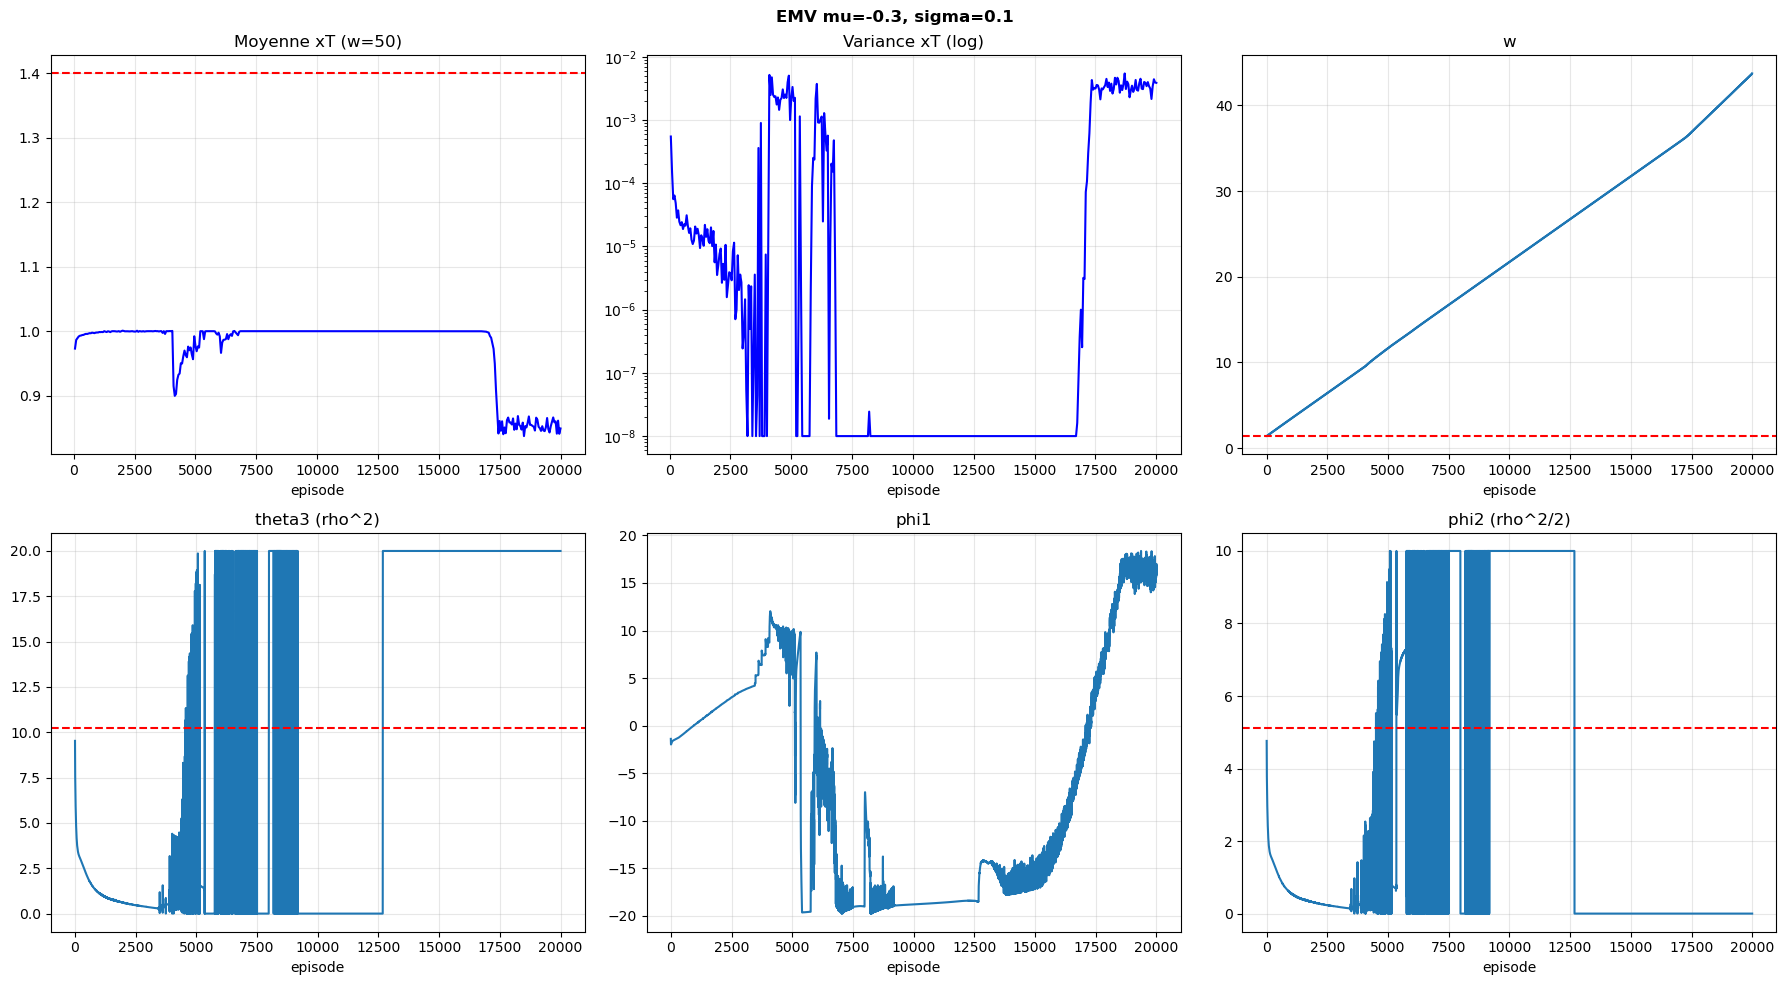

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
xT = emv['xT']; w50=50; nw=len(xT)//w50
means = [xT[i*w50:(i+1)*w50].mean() for i in range(nw)]
varis = [xT[i*w50:(i+1)*w50].var() for i in range(nw)]
ep = np.arange(1,nw+1)*w50

axes[0,0].plot(ep,means,'b-'); axes[0,0].axhline(z,color='r',ls='--')
axes[0,0].set_title('Moyenne xT (w=50)'); axes[0,0].set_xlabel('episode')

axes[0,1].semilogy(ep,np.maximum(varis,1e-8),'b-')
axes[0,1].set_title('Variance xT (log)'); axes[0,1].set_xlabel('episode')

axes[0,2].plot(emv['w']); axes[0,2].axhline(compute_w_star(rho_true),color='r',ls='--')
axes[0,2].set_title('w'); axes[0,2].set_xlabel('episode')

axes[1,0].plot(emv['theta3']); axes[1,0].axhline(rho_true**2,color='r',ls='--')
axes[1,0].set_title('theta3 (rho^2)'); axes[1,0].set_xlabel('episode')

axes[1,1].plot(emv['phi1']); axes[1,1].set_title('phi1'); axes[1,1].set_xlabel('episode')

axes[1,2].plot(emv['phi2']); axes[1,2].axhline(rho_true**2/2,color='r',ls='--')
axes[1,2].set_title('phi2 (rho^2/2)'); axes[1,2].set_xlabel('episode')

plt.suptitle(f'EMV mu={mu_test}, sigma={sigma_test}', fontweight='bold')
plt.tight_layout(); plt.show()

In [9]:
import numpy as np
import random

# Optionnel mais utile si run_emv / run_mle utilisent aussi d'autres générateurs aléatoires
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

def safe_sr(mean_x, var_x):
    return (mean_x - 1.0) / np.sqrt(var_x) if var_x > 1e-12 else 0.0

def run_one_case_like_grid(mu_test=-0.30, sigma_test=0.10, M_emv=5000, eval_last=2000):
    # même seed que dans la grille
    seed = 12345 + int((mu_test + 1) * 1000) + int(sigma_test * 10000)

    # ---- EMV ----
    set_all_seeds(seed)
    emv = run_emv(mu_test, sigma_test, M=M_emv, seed=seed)
    le = np.asarray(emv['xT'][-eval_last:], dtype=float)
    me, ve = le.mean(), le.var()
    sre = safe_sr(me, ve)

    # ---- MLE ----
    set_all_seeds(seed)
    mle = run_mle(mu_test, sigma_test, M=M_emv, seed=seed)
    lm = np.asarray(mle['xT'][-eval_last:], dtype=float)
    mm, vm = lm.mean(), lm.var()
    srm = safe_sr(mm, vm)

    best = "E" if sre > srm else "M"

    print(f"{'Scenario':>20s} | {'--- EMV ---':^26s} | {'--- MLE ---':^26s} | W")
    print(f"{'':>20s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} |")
    print("-" * 82)
    print(f"{'[1/1] mu=' + format(mu_test, '+.0%') + ' s=' + format(sigma_test, '.0%'):>20s} | "
          f"{me:7.3f} {ve:7.4f} {sre:7.3f} | "
          f"{mm:7.3f} {vm:7.4f} {srm:7.3f} | {best}")

    return {
        "mu": mu_test,
        "sigma": sigma_test,
        "seed": seed,
        "EMV_mean": me,
        "EMV_var": ve,
        "EMV_SR": sre,
        "MLE_mean": mm,
        "MLE_var": vm,
        "MLE_SR": srm,
        "winner": best,
        "emv_obj": emv,
        "mle_obj": mle
    }

# ===== Exécution du cas unique exactement comme dans la grille =====
res_single = run_one_case_like_grid(mu_test=-0.30, sigma_test=0.10, M_emv=5000, eval_last=2000)

            Scenario |        --- EMV ---         |        --- MLE ---         | W
                     |    Mean     Var      SR |    Mean     Var      SR |
----------------------------------------------------------------------------------
 [1/1] mu=-30% s=10% |   0.974  0.0025  -0.521 |   0.993  0.0003  -0.425 | M


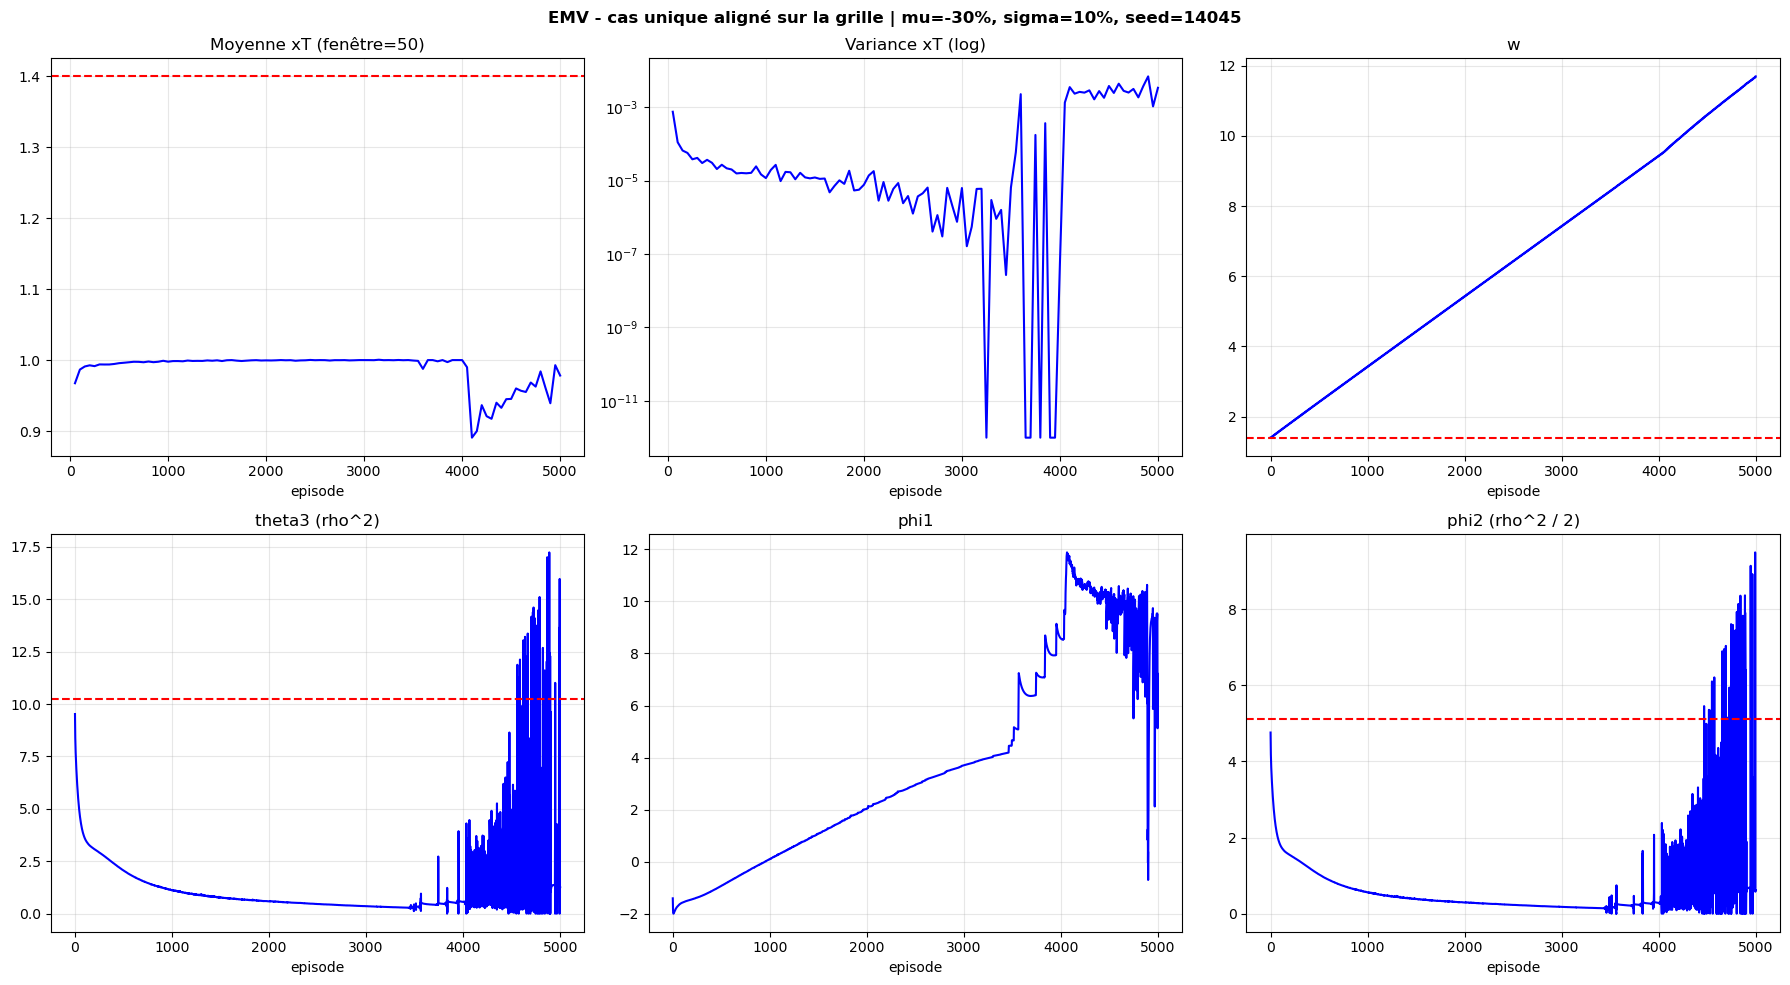

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Choix du run à tracer
# - res_single      : même protocole que la grille (M=5000)
# - res_single_20k  : version plus longue si tu l'as calculée
# ============================================================
res_plot = res_single
# res_plot = res_single_20k

emv = res_plot["emv_obj"]
mu_test = res_plot["mu"]
sigma_test = res_plot["sigma"]
seed_used = res_plot["seed"]

# Hypothèses : r_rate et compute_w_star existent déjà dans le notebook
rho_true = (mu_test - r_rate) / sigma_test
w_star = compute_w_star(rho_true)

# On récupère les trajectoires
xT = np.asarray(emv["xT"], dtype=float)
w_path = np.asarray(emv["w"], dtype=float)
theta3_path = np.asarray(emv["theta3"], dtype=float)
phi1_path = np.asarray(emv["phi1"], dtype=float)
phi2_path = np.asarray(emv["phi2"], dtype=float)

# ============================================================
# Statistiques glissantes sur xT
# ============================================================
w50 = 50
nw = len(xT) // w50
xT_trim = xT[:nw * w50]

means = np.array([xT_trim[i*w50:(i+1)*w50].mean() for i in range(nw)])
varis = np.array([xT_trim[i*w50:(i+1)*w50].var() for i in range(nw)])
ep = np.arange(1, nw + 1) * w50

# Cible de richesse terminale : utilise z si déjà défini dans le notebook,
# sinon prend 1.4 par défaut
z_plot = globals().get("z", 1.4)

# ============================================================
# Figures
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1) Moyenne glissante de xT
axes[0, 0].plot(ep, means, 'b-')
axes[0, 0].axhline(z_plot, color='r', ls='--')
axes[0, 0].set_title(f"Moyenne xT (fenêtre={w50})")
axes[0, 0].set_xlabel("episode")

# 2) Variance glissante de xT (log)
axes[0, 1].semilogy(ep, np.maximum(varis, 1e-12), 'b-')
axes[0, 1].set_title("Variance xT (log)")
axes[0, 1].set_xlabel("episode")

# 3) Poids w
axes[0, 2].plot(w_path, 'b-')
axes[0, 2].axhline(w_star, color='r', ls='--')
axes[0, 2].set_title("w")
axes[0, 2].set_xlabel("episode")

# 4) theta3
axes[1, 0].plot(theta3_path, 'b-')
axes[1, 0].axhline(rho_true**2, color='r', ls='--')
axes[1, 0].set_title("theta3 (rho^2)")
axes[1, 0].set_xlabel("episode")

# 5) phi1
axes[1, 1].plot(phi1_path, 'b-')
axes[1, 1].set_title("phi1")
axes[1, 1].set_xlabel("episode")

# 6) phi2
axes[1, 2].plot(phi2_path, 'b-')
axes[1, 2].axhline(rho_true**2 / 2, color='r', ls='--')
axes[1, 2].set_title("phi2 (rho^2 / 2)")
axes[1, 2].set_xlabel("episode")

plt.suptitle(
    f"EMV - cas unique aligné sur la grille | mu={mu_test:+.0%}, sigma={sigma_test:.0%}, seed={seed_used}",
    fontweight="bold"
)
plt.tight_layout()
plt.show()

In [11]:
mu_values = [-0.50, -0.30, -0.10, 0.0, 0.10, 0.30, 0.50]
sigma_values = [0.10, 0.20, 0.30, 0.40]
M_emv = 5000  # reduire a 5000 pour test rapide
eval_last = 2000

results = []
total = len(mu_values) * len(sigma_values)
count = 0

print(f"{'Scenario':>20s} | {'--- EMV ---':^26s} | {'--- MLE ---':^26s} | W")
print(f"{'':>20s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} | {'Mean':>7s} {'Var':>7s} {'SR':>7s} |")
print("-" * 82)

for sigma in sigma_values:
    for mu in mu_values:
        count += 1
        seed = 12345 + int((mu+1)*1000) + int(sigma*10000)
        
        emv = run_emv(mu, sigma, M=M_emv, seed=seed)
        le = emv['xT'][-eval_last:]
        me,ve = le.mean(), le.var()
        sre = (me-1)/np.sqrt(ve) if ve > 1e-12 else 0
        
        mle = run_mle(mu, sigma, M=M_emv, seed=seed)
        lm = mle['xT'][-eval_last:]
        mm,vm = lm.mean(), lm.var()
        srm = (mm-1)/np.sqrt(vm) if vm > 1e-12 else 0
        
        best = "E" if sre > srm else "M"
        print(f"[{count:2d}/{total}] mu={mu:+.0%} s={sigma:.0%} | {me:7.3f} {ve:7.4f} {sre:7.3f} | {mm:7.3f} {vm:7.4f} {srm:7.3f} | {best}")
        results.append(dict(mu=mu,sigma=sigma,EMV_mean=me,EMV_var=ve,EMV_SR=sre,
                            MLE_mean=mm,MLE_var=vm,MLE_SR=srm))

print("-" * 82)
nw = sum(1 for r in results if r['EMV_SR'] > r['MLE_SR'])
print(f"EMV gagne en SR : {nw}/{total} ({nw/total:.0%})")

            Scenario |        --- EMV ---         |        --- MLE ---         | W
                     |    Mean     Var      SR |    Mean     Var      SR |
----------------------------------------------------------------------------------
[ 1/28] mu=-50% s=10% |   0.959  0.0052  -0.564 |   1.000  0.0000  -0.087 | M
[ 2/28] mu=-30% s=10% |   0.974  0.0025  -0.521 |   0.993  0.0003  -0.425 | M
[ 3/28] mu=-10% s=10% |   0.992  0.0009  -0.285 |   0.974  0.0014  -0.706 | E
[ 4/28] mu=+0% s=10% |   0.998  0.0008  -0.059 |   0.989  0.0041  -0.167 | E
[ 5/28] mu=+10% s=10% |   1.083  0.0116   0.766 |   1.057  0.0101   0.566 | E
[ 6/28] mu=+30% s=10% |   1.245  0.0083   2.687 |   1.285  0.0126   2.540 | E
[ 7/28] mu=+50% s=10% |   1.318  0.0049   4.557 |   1.395  0.0008  14.084 | M
[ 8/28] mu=-50% s=20% |   0.978  0.0038  -0.351 |   0.973  0.0022  -0.570 | E
[ 9/28] mu=-30% s=20% |   0.986  0.0025  -0.272 |   0.949  0.0043  -0.782 | E
[10/28] mu=-10% s=20% |   0.994  0.0016  -0.147 |   0.957 

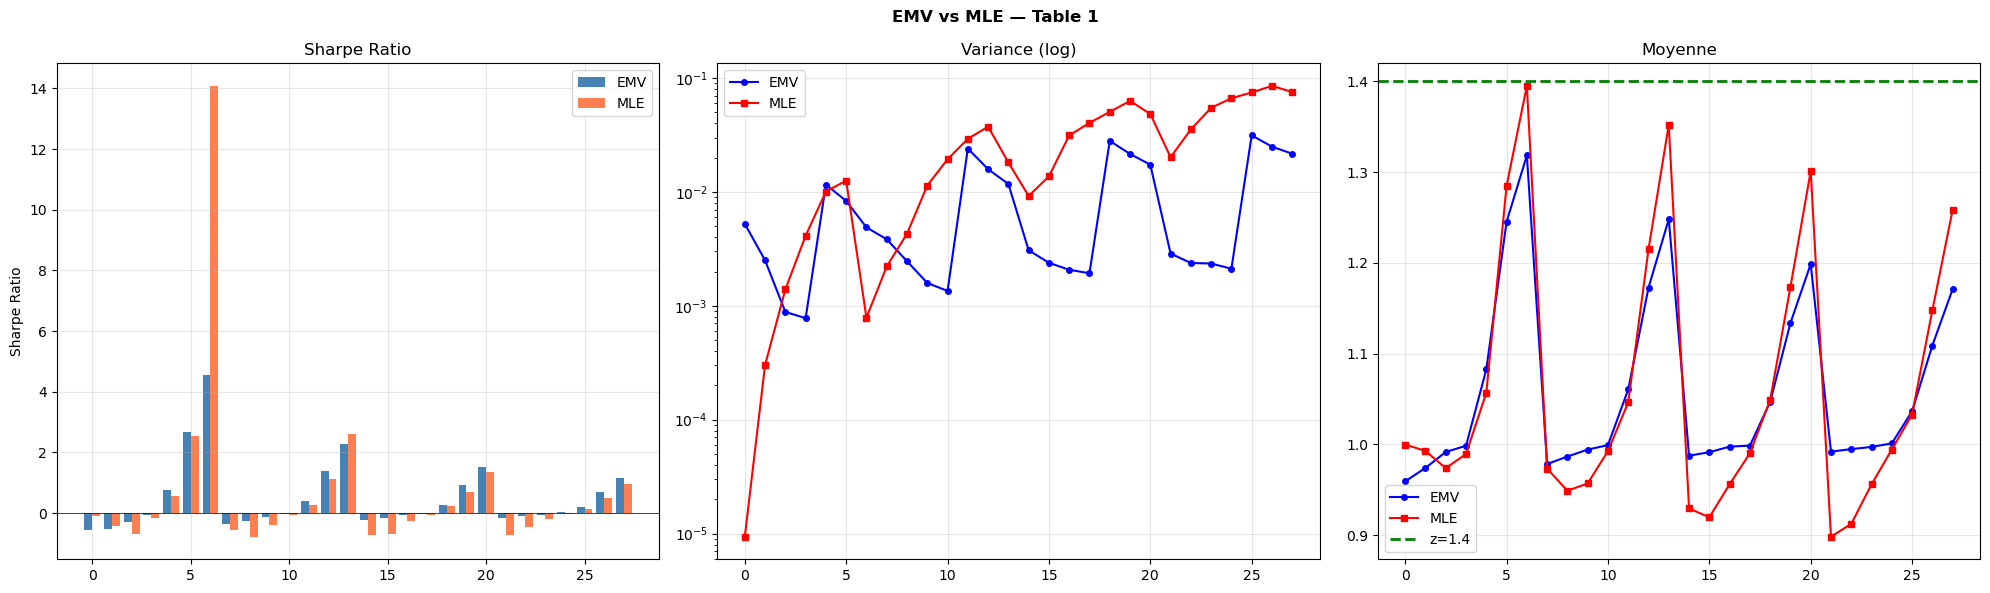

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
xp = np.arange(len(results))

ax = axes[0]
ax.bar(xp-0.2, [r['EMV_SR'] for r in results], 0.4, label='EMV', color='steelblue')
ax.bar(xp+0.2, [r['MLE_SR'] for r in results], 0.4, label='MLE', color='coral')
ax.set_ylabel('Sharpe Ratio'); ax.set_title('Sharpe Ratio'); ax.legend()
ax.axhline(0,color='k',lw=0.5)

ax = axes[1]
ax.semilogy([r['EMV_var'] for r in results], 'bo-', ms=4, label='EMV')
ax.semilogy([r['MLE_var'] for r in results], 'rs-', ms=4, label='MLE')
ax.set_title('Variance (log)'); ax.legend()

ax = axes[2]
ax.plot([r['EMV_mean'] for r in results], 'bo-', ms=4, label='EMV')
ax.plot([r['MLE_mean'] for r in results], 'rs-', ms=4, label='MLE')
ax.axhline(z,color='g',ls='--',lw=2, label=f'z={z}')
ax.set_title('Moyenne'); ax.legend()

plt.suptitle('EMV vs MLE — Table 1', fontweight='bold')
plt.tight_layout(); plt.show()


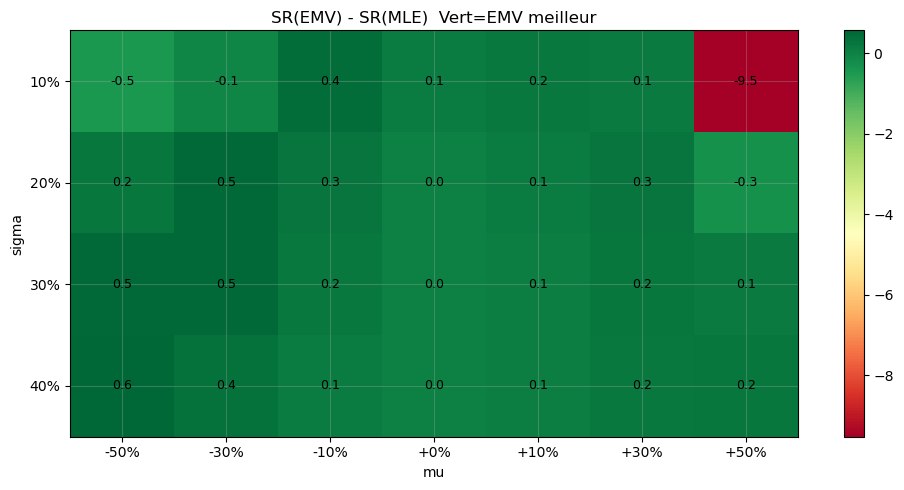

In [13]:
# Heatmap
sr_diff = np.zeros((len(sigma_values), len(mu_values)))
for r in results:
    i = sigma_values.index(r['sigma'])
    j = mu_values.index(r['mu'])
    sr_diff[i,j] = r['EMV_SR'] - r['MLE_SR']

fig, ax = plt.subplots(figsize=(10,5))
im = ax.imshow(sr_diff, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(mu_values))); ax.set_xticklabels([f'{m:+.0%}' for m in mu_values])
ax.set_yticks(range(len(sigma_values))); ax.set_yticklabels([f'{s:.0%}' for s in sigma_values])
ax.set_xlabel('mu'); ax.set_ylabel('sigma')
ax.set_title('SR(EMV) - SR(MLE)  Vert=EMV meilleur')
for i in range(len(sigma_values)):
    for j in range(len(mu_values)):
        ax.text(j,i,f'{sr_diff[i,j]:.1f}',ha='center',va='center',fontsize=9)
plt.colorbar(im); plt.tight_layout(); plt.show()

In [ ]:
def target_from_annualized_return(T, annual_return=0.40, x0=1.0):
    """Cible terminale correspondant a un objectif annualise constant."""
    return x0 * (1.0 + annual_return) ** T

def terminal_stats(xT, eval_last=2000, x0=1.0, sr_mode='paper'):
    """Resume les dernieres richesses terminales.

    sr_mode='paper'   -> SR = mean / sqrt(var)
    sr_mode='excess'  -> SR = (mean - x0) / sqrt(var)
    """
    tail = np.asarray(xT[-eval_last:], dtype=float)
    mean_ = float(np.mean(tail))
    var_ = float(np.var(tail))
    if var_ <= 1e-12:
        sr_ = 0.0
    else:
        if sr_mode == 'paper':
            sr_ = float(mean_ / np.sqrt(var_))
        elif sr_mode == 'excess':
            sr_ = float((mean_ - x0) / np.sqrt(var_))
        else:
            raise ValueError("sr_mode doit etre 'paper' ou 'excess'")
    return {'mean': mean_, 'var': var_, 'sr': sr_, 'tail': tail}

def compare_single_scenario_by_maturity(mu, sigma, T_values=(0.5, 1.0, 2.0),
                                        x0=1.0, r=0.02, dt=1/252,
                                        target_mode='annualized',
                                        z_fixed=1.4,
                                        annual_return=0.40,
                                        M=5000, eval_last=2000, seed0=2026):
    """Compare EMV et MLE pour plusieurs maturites sur un scenario (mu, sigma)."""
    rows = []
    for idx, T_ in enumerate(T_values):
        if target_mode == 'annualized':
            z_ = target_from_annualized_return(T_, annual_return=annual_return, x0=x0)
        elif target_mode == 'fixed':
            z_ = z_fixed
        else:
            raise ValueError("target_mode doit etre 'annualized' ou 'fixed'")

        seed = seed0 + idx * 1000 + int((mu + 1.0) * 1000) + int(sigma * 10000) + int(T_ * 100)
        emv_res = run_emv(mu, sigma, r=r, x0=x0, z=z_, T=T_, dt=dt, M=M, seed=seed)
        mle_res = run_mle(mu, sigma, r=r, x0=x0, z=z_, T=T_, dt=dt, M=M, seed=seed)

        emv_stats = terminal_stats(emv_res['xT'], eval_last=eval_last, x0=x0, sr_mode='paper')
        mle_stats = terminal_stats(mle_res['xT'], eval_last=eval_last, x0=x0, sr_mode='paper')

        rows.append({
            'T': T_,
            'n_steps': int(round(T_ / dt)),
            'z': z_,
            'EMV_mean': emv_stats['mean'],
            'EMV_var': emv_stats['var'],
            'EMV_SR': emv_stats['sr'],
            'MLE_mean': mle_stats['mean'],
            'MLE_var': mle_stats['var'],
            'MLE_SR': mle_stats['sr'],
            'EMV_xT': emv_res['xT'],
            'MLE_xT': mle_res['xT'],
            'EMV_w': emv_res['w'],
            'EMV_theta3': emv_res['theta3'],
        })
    return rows

print("Fonctions maturite definies.") 

Fonctions maturite definies.


In [ ]:
mu_mat, sigma_mat = -0.50, 0.10
T_values = [0.25,0.5, 1.0, 2.0, 3.0]

maturity_rows_ann = compare_single_scenario_by_maturity(
    mu=mu_mat,
    sigma=sigma_mat,
    T_values=T_values,
    x0=x0,
    r=r_rate,
    dt=dt,
    target_mode='annualized',
    annual_return=0.40,
    M=5000,
    eval_last=2000,
    seed0=4242
)

print(f"{'T':>6s} {'pas':>6s} {'z(T)':>8s} | {'EMV mean':>9s} {'EMV var':>10s} {'EMV SR':>8s} | {'MLE mean':>9s} {'MLE var':>10s} {'MLE SR':>8s}")
print("-"*90)
for row in maturity_rows_ann:
    print(f"{row['T']:6.2f} {row['n_steps']:6d} {row['z']:8.4f} | "
          f"{row['EMV_mean']:9.4f} {row['EMV_var']:10.4f} {row['EMV_SR']:8.4f} | "
          f"{row['MLE_mean']:9.4f} {row['MLE_var']:10.4f} {row['MLE_SR']:8.4f}")

     T    pas     z(T) |  EMV mean    EMV var   EMV SR |  MLE mean    MLE var   MLE SR
------------------------------------------------------------------------------------------
  0.25     63   1.0878 |    0.9992     0.0000 320.4173 |    0.9999     0.0000 597.8879
  0.50    126   1.1832 |    0.9999     0.0000 616.0005 |    0.9999     0.0000 405.2787
  1.00    252   1.4000 |    0.9602     0.0054  13.1193 |    0.9997     0.0000 297.0177
  2.00    504   1.9600 |    0.9737     0.0013  27.3104 |    0.9992     0.0000 179.2569
  3.00    756   2.7440 |    0.8664     0.0336   4.7274 |    0.9989     0.0000 141.3031


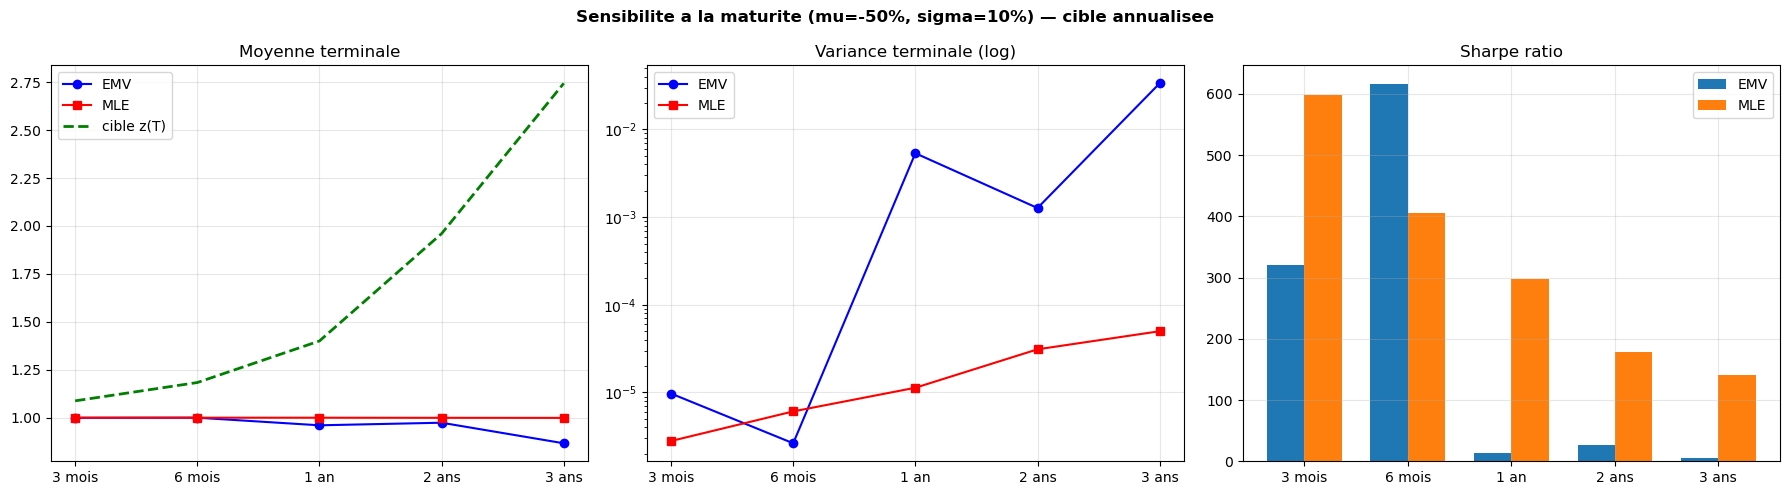

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['3 mois', '6 mois', '1 an', '2 ans', '3 ans']
xp = np.arange(len(maturity_rows_ann))

axes[0].plot(xp, [r['EMV_mean'] for r in maturity_rows_ann], 'bo-', label='EMV')
axes[0].plot(xp, [r['MLE_mean'] for r in maturity_rows_ann], 'rs-', label='MLE')
axes[0].plot(xp, [r['z'] for r in maturity_rows_ann], 'g--', lw=2, label='cible z(T)')
axes[0].set_xticks(xp); axes[0].set_xticklabels(labels)
axes[0].set_title('Moyenne terminale'); axes[0].legend()

axes[1].semilogy(xp, [max(r['EMV_var'],1e-12) for r in maturity_rows_ann], 'bo-', label='EMV')
axes[1].semilogy(xp, [max(r['MLE_var'],1e-12) for r in maturity_rows_ann], 'rs-', label='MLE')
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels)
axes[1].set_title('Variance terminale (log)'); axes[1].legend()

axes[2].bar(xp-0.18, [r['EMV_SR'] for r in maturity_rows_ann], width=0.36, label='EMV')
axes[2].bar(xp+0.18, [r['MLE_SR'] for r in maturity_rows_ann], width=0.36, label='MLE')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].set_xticks(xp); axes[2].set_xticklabels(labels)
axes[2].set_title('Sharpe ratio')
axes[2].legend()

plt.suptitle(f'Sensibilite a la maturite (mu={mu_mat:+.0%}, sigma={sigma_mat:.0%}) — cible annualisee', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
maturity_rows_fixed = compare_single_scenario_by_maturity(
    mu=mu_mat,
    sigma=sigma_mat,
    T_values=T_values,
    x0=x0,
    r=r_rate,
    dt=dt,
    target_mode='fixed',
    z_fixed=1.4,
    M=5000,
    eval_last=2000,
    seed0=4242
)

print(f"{'T':>6s} {'pas':>6s} {'z':>8s} | {'EMV mean':>9s} {'EMV var':>10s} {'EMV SR':>8s} | {'MLE mean':>9s} {'MLE var':>10s} {'MLE SR':>8s}")
print("-"*90)
for row in maturity_rows_fixed:
    print(f"{row['T']:6.2f} {row['n_steps']:6d} {row['z']:8.4f} | "
          f"{row['EMV_mean']:9.4f} {row['EMV_var']:10.4f} {row['EMV_SR']:8.4f} | "
          f"{row['MLE_mean']:9.4f} {row['MLE_var']:10.4f} {row['MLE_SR']:8.4f}")

     T    pas        z |  EMV mean    EMV var   EMV SR |  MLE mean    MLE var   MLE SR
------------------------------------------------------------------------------------------
  0.25     63   1.4000 |    0.9991     0.0001 137.2090 |    0.9999     0.0000 597.8879
  0.50    126   1.4000 |    0.9439     0.0047  13.7830 |    0.9999     0.0000 405.2787
  1.00    252   1.4000 |    0.9602     0.0054  13.1193 |    0.9997     0.0000 297.0177
  2.00    504   1.4000 |    0.9698     0.0065  11.9909 |    0.9992     0.0000 179.2569
  3.00    756   1.4000 |    0.9556     0.0134   8.2625 |    0.9989     0.0000 141.3031


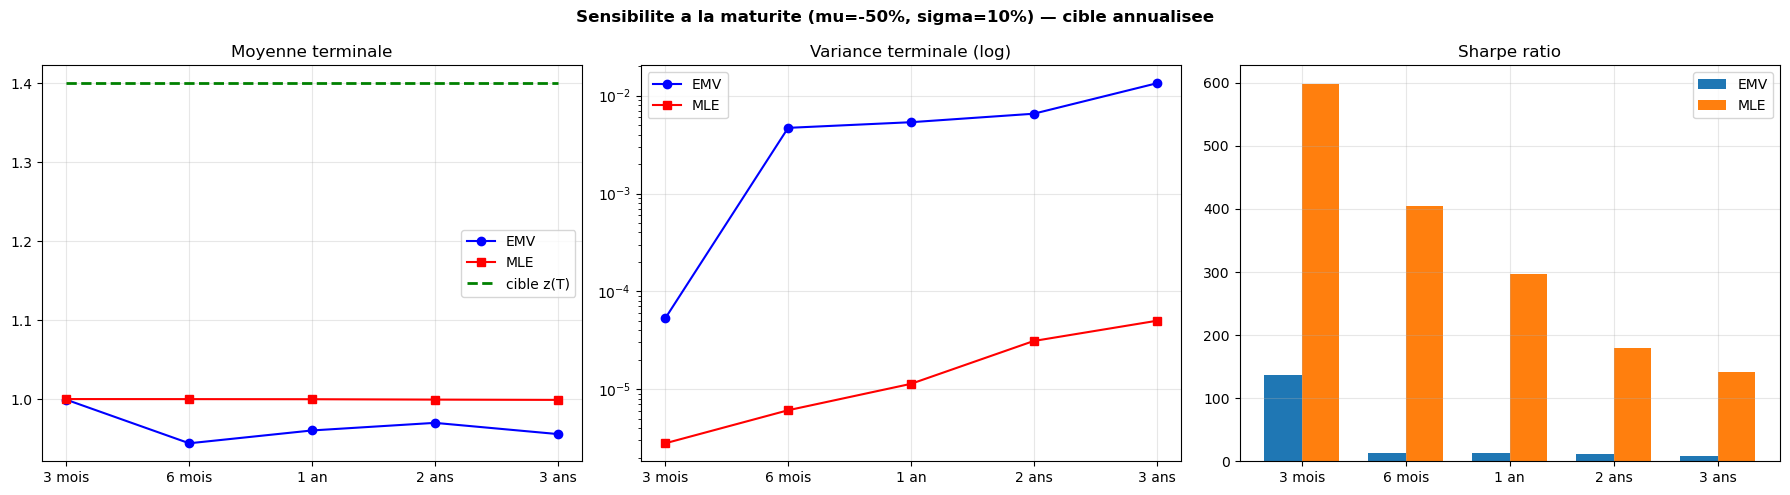

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['3 mois', '6 mois', '1 an', '2 ans', '3 ans']
xp = np.arange(len(maturity_rows_fixed))

axes[0].plot(xp, [r['EMV_mean'] for r in maturity_rows_fixed], 'bo-', label='EMV')
axes[0].plot(xp, [r['MLE_mean'] for r in maturity_rows_fixed], 'rs-', label='MLE')
axes[0].plot(xp, [r['z'] for r in maturity_rows_fixed], 'g--', lw=2, label='cible z(T)')
axes[0].set_xticks(xp); axes[0].set_xticklabels(labels)
axes[0].set_title('Moyenne terminale'); axes[0].legend()

axes[1].semilogy(xp, [max(r['EMV_var'],1e-12) for r in maturity_rows_fixed], 'bo-', label='EMV')
axes[1].semilogy(xp, [max(r['MLE_var'],1e-12) for r in maturity_rows_fixed], 'rs-', label='MLE')
axes[1].set_xticks(xp); axes[1].set_xticklabels(labels)
axes[1].set_title('Variance terminale (log)'); axes[1].legend()

axes[2].bar(xp-0.18, [r['EMV_SR'] for r in maturity_rows_fixed], width=0.36, label='EMV')
axes[2].bar(xp+0.18, [r['MLE_SR'] for r in maturity_rows_fixed], width=0.36, label='MLE')
axes[2].axhline(0, color='k', lw=0.6)
axes[2].set_xticks(xp); axes[2].set_xticklabels(labels)
axes[2].set_title('Sharpe ratio')
axes[2].legend()

plt.suptitle(f'Sensibilite a la maturite (mu={mu_mat:+.0%}, sigma={sigma_mat:.0%}) — cible annualisee', fontweight='bold')
plt.tight_layout()
plt.show()
